# Topological Machine Learning with the Mapper Algorithm
#### This notebook is prepared by **Aman Raj**

---



#### Here I want to say that we can use the mapper to visualize more complex datasets such as MNIST.

## Part 2: Mapper on MNIST dataset

In [9]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
import sklearn
import matplotlib.pyplot as plt
import numpy as np

# Topological data analysis
import kmapper as km
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

Loading MNIST data...
Data shape: (25000, 784)
Labels: [0 1 2 3 4 5 6 7 8 9]


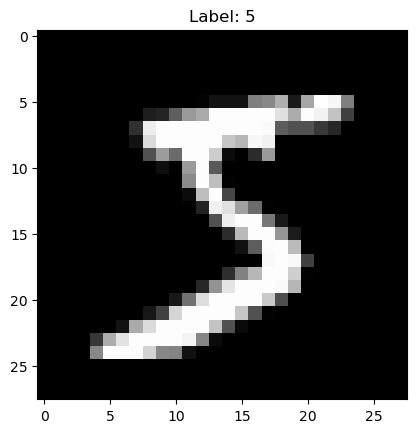

In [5]:
# 1. Load Data (MNIST)
# We use a subset (e.g., 25000 samples) to speed up computation for t-SNE/Isomap
print("Loading MNIST data...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X = mnist.data.astype('float32')
y = mnist.target.astype('int')

# Subsample for efficiency (optional, but recommended for t-SNE/Isomap)
SUBSAMPLE = 25000
X_subset = X[:SUBSAMPLE]
y_subset = y[:SUBSAMPLE]

# 2. Normalize (Scale pixel values to [0, 1])
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_subset)

print(f"Data shape: {X_scaled.shape}")
print(f"Labels: {np.unique(y_subset)}")

# Preview a digit
plt.imshow(X_subset[0].reshape(28, 28), cmap='gray')
plt.title(f"Label: {y_subset[0]}")
plt.show()

We will initialize the `KeplerMapper` object and experiment with three different filter functions (lenses):
1.  **L2-Norm:** Measures magnitude/intensity of the digit.
2.  **PCA (Principal Component Analysis):** Captures maximum variance (global structure).
3.  **Isomap / t-SNE:** Captures non-linear manifold structure.

### Initialization

In [6]:
# Initialize KeplerMapper
mapper = km.KeplerMapper(verbose=1)

# Tooltip for visualization (shows the true label when hovering over nodes)
tooltips = y_subset.astype(str)

KeplerMapper(verbose=1)


### Experiment 2A: L2-Norm Lens
The L2-norm filter $f(x) = ||x||_2$ maps each image to its Euclidean length. For MNIST, this roughly corresponds to the amount of "ink" or stroke thickness in the digit.

In [7]:
# 1. Define Lens
lens_l2 = mapper.fit_transform(X_scaled, projection="l2norm")

# 2. Build Graph - FIXED PARAMETERS
graph_l2 = mapper.map(
    lens_l2, 
    X_scaled, 
    cover=km.Cover(n_cubes=15, perc_overlap=0.2),  # HIGHER OVERLAP
    clusterer=sklearn.cluster.DBSCAN(eps=5, min_samples=20)  # LOOSER PARAMS
)

print(f"Nodes created: {len(graph_l2['nodes'])}")
print(f"Edges created: {len(graph_l2['links'])}")

# 3. Visualize
html_l2 = mapper.visualize(
    graph_l2, 
    path_html="mnist_l2norm.html",
    title="MNIST Mapper - L2 Norm Lens (Fixed)",
    custom_tooltips=tooltips,
    color_values=y_subset,
    color_function_name="Digit Label"
)

..Composing projection pipeline of length 1:
	Projections: l2norm
	Distance matrices: False
	Scalers: MinMaxScaler()
..Projecting on data shaped (25000, 784)

..Projecting data using: l2norm

..Scaling with: MinMaxScaler()

Mapping on data shaped (25000, 784) using lens shaped (25000, 1)

Creating 15 hypercubes.

Created 21 edges and 25 nodes in 0:00:01.950396.
Nodes created: 25
Edges created: 15
Wrote visualization to: mnist_l2norm.html


![mnist_l2norm.png](Mapper_html_outputs_and_images/mnist_l2norm.png)

**Interpretation of L2-Norm:**
- The L²‑norm lens yields a **tree‑like structure** with one large central node and several branches radiating out, plus a small square‑shaped loop in one corner.  
- The coloring indicates that digits are **ordered roughly by stroke intensity** along the branches (low‑ink digits near one side, high‑ink digits on another), but many branches mix multiple labels, showing that norm alone cannot cleanly separate classes and mainly captures “amount of ink” rather than digit identity.

### Experiment 2B: PCA Lens (2 Components)
PCA projects the data onto the axes of maximum variance.

In [10]:
# 1. Define Lens
pca_lens = mapper.fit_transform(X_scaled, projection=PCA(n_components=2))

# 2. Build Graph
graph_pca = mapper.map(
    pca_lens, 
    X_scaled, 
    cover=km.Cover(n_cubes=15, perc_overlap=0.2), # Higher resolution
    clusterer=sklearn.cluster.DBSCAN(eps=5, min_samples=20)
)

# 3. Visualize
html_pca = mapper.visualize(
    graph_pca, 
    path_html="mnist_pca.html",
    title="MNIST Mapper - PCA Lens (2D)",
    custom_tooltips=tooltips,
    color_values=y_subset,
    color_function_name="Digit Label"
)
# IFrame(src="mnist_pca.html", width=800, height=600)

..Composing projection pipeline of length 1:
	Projections: PCA(n_components=2)
	Distance matrices: False
	Scalers: MinMaxScaler()
..Projecting on data shaped (25000, 784)

..Projecting data using: 
	PCA(n_components=2)


..Scaling with: MinMaxScaler()

Mapping on data shaped (25000, 784) using lens shaped (25000, 2)

Creating 225 hypercubes.

Created 107 edges and 46 nodes in 0:00:01.034334.
Wrote visualization to: mnist_pca.html


![mnist_pca.png](Mapper_html_outputs_and_images/mnist_pca.png)

**Interpretation of PCA:**
- The PCA lens produces a Mapper graph that looks like a **bent, ribbon‑shaped manifold** with a few short off‑shoots and sparse outliers.  
- Along this ribbon the color gradually changes, indicating a **continuous progression of digit classes**; some sub‑regions are dominated by a single label, while transition zones show mixtures, reflecting that PCA captures a low‑dimensional “skeleton” of digit variation but still overlaps visually similar digits.

### Experiment 2C: tsne Lens (Manifold Learning)
tsne preserves geodesic distances, often unfolding the "manifold" of the digits better than linear PCA.

In [11]:
# 1. Define Lens
tsne_lens = mapper.fit_transform(X_scaled, projection=TSNE())

# 2. Build Graph
# We increase n_cubes because Isomap separates classes better, allowing for finer resolution
graph_tsne = mapper.map(
    tsne_lens, 
    X_scaled, 
    cover=km.Cover(n_cubes=15, perc_overlap=0.2), 
    clusterer=sklearn.cluster.DBSCAN(eps=5, min_samples=20)
)

# 3. Visualize
html_tsne = mapper.visualize(
    graph_tsne, 
    path_html="mnist_tsne.html",
    title="MNIST Mapper - tsne Lens",
    custom_tooltips=tooltips,
    color_values=y_subset, 
    color_function_name="Digit Label"
)

..Composing projection pipeline of length 1:
	Projections: TSNE()
	Distance matrices: False
	Scalers: MinMaxScaler()
..Projecting on data shaped (25000, 784)

..Projecting data using: 
	TSNE(verbose=1)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 25000 samples in 0.044s...
[t-SNE] Computed neighbors for 25000 samples in 5.518s...
[t-SNE] Computed conditional probabilities for sample 1000 / 25000
[t-SNE] Computed conditional probabilities for sample 2000 / 25000
[t-SNE] Computed conditional probabilities for sample 3000 / 25000
[t-SNE] Computed conditional probabilities for sample 4000 / 25000
[t-SNE] Computed conditional probabilities for sample 5000 / 25000
[t-SNE] Computed conditional probabilities for sample 6000 / 25000
[t-SNE] Computed conditional probabilities for sample 7000 / 25000
[t-SNE] Computed conditional probabilities for sample 8000 / 25000
[t-SNE] Computed conditional probabilities for sample 9000 / 25000
[t-SNE] Computed conditional probabilities for samp

![mnist_tsne.png](Mapper_html_outputs_and_images/mnist_tsne.png)

**Interpretation of tsne:**
- The t‑SNE lens produces a **highly fragmented Mapper graph** with many small components and several dense “blob‑like” regions connected by short bridges.  
- Nodes are colored by digit label, and clusters tend to be **locally pure** (same or similar digits), but globally the layout shows that different digit manifolds are **well separated into distinct islands** with only a few ambiguous connector nodes at the edges of these islands.

---
## Interpretation & Insights of mapper on MNIST

### Parameter Sensitivity
*   **Overlap (Gain):** Increasing overlap (e.g., > 50%) makes the graph more connected. If overlap is too low, the graph shatters into many tiny, disconnected components (discrete points).
*   **Resolution (n_cubes):** 
    *   **Low (e.g., 5):** The graph is a "blob." All digits merge into one giant node.
    *   **High (e.g., 30):** The graph becomes a "cloud" of points, similar to the original scatter plot, losing the topological summary benefit.
    *   **Sweet Spot (10-20):** Shows the "skeleton" of the data, revealing transitions between digits (e.g., a '9' morphing into a '4').

### Digit Separation
*   **Class '1':** Almost always distinct due to its unique geometric shape (thin, vertical).
*   **Classes '3', '5', '8':** These often form a complex "bumpy" region or a loop because they share curvilinear features.
*   **Ambiguous Regions:** The "edges" in the Mapper graph between a cluster dominated by '9's and a cluster dominated by '4's represent truly ambiguous handwriting—digits that look like both.

### Note:
These three views together support the story that different lenses emphasize different aspects of the MNIST topology:  
t‑SNE gives many locally pure components, L²‑norm arranges digits by intensity, and PCA uncovers a global low‑dimensional backbone with smooth transitions between digit types.


---

We mostly saw visualization as an application of mapper, but it has various applications and in a variety of fields

![Different_fields.png](Mapper_html_outputs_and_images/Different_fields.png)

## Challenges

![challenges.png](Mapper_html_outputs_and_images/challenges.png)

## Future Directions

![Future_directions.png](Mapper_html_outputs_and_images/Future_directions.png)

## Conclusion

![Conclusion.png](Mapper_html_outputs_and_images/Conclusion.png)

---
# References

## Software and Libraries

| Library | Version | Purpose | Citation |
|---------|---------|---------|----------|
| **KeplerMapper** | 2.1.0 | Topological data analysis and Mapper implementation | van Veen et al. (2019) |
| **scikit-learn** | Latest | Machine learning, PCA, DBSCAN, datasets | Pedregosa et al. (2011) |
| **UMAP** | Latest | Uniform manifold approximation and projection | McInnes et al. (2018) |
| **t-SNE** | via sklearn | t-distributed stochastic neighbor embedding | van der Maaten & Hinton (2008) |
| **NumPy** | Latest | Numerical computing | Harris et al. (2020) |
| **Matplotlib** | Latest | Data visualization | Hunter (2007) |

---

## Key Papers

### Mapper Algorithm

1. **Singh, G., Mémoli, F., & Carlsson, G. E.** (2007). *Topological Methods for the Analysis of High Dimensional Data Sets and 3D Object Recognition.* Eurographics Symposium on Point-Based Graphics.
   - Original Mapper algorithm paper

2. **Carlsson, G.** (2009). *Topology and Data.* Bulletin of the American Mathematical Society, 46(2), 255-308.
   - Foundational paper on topological data analysis

### Implementations

3. **van Veen, H. J., Saul, N., Eargle, D., & Mangham, S. W.** (2019). *Kepler Mapper: A Flexible Python Implementation of the Mapper Algorithm.* Journal of Open Source Software, 4(42), 1315.
   - KeplerMapper software paper

### Dimensionality Reduction

4. **van der Maaten, L., & Hinton, G.** (2008). *Visualizing Data using t-SNE.* Journal of Machine Learning Research, 9, 2579-2605.
   - t-SNE algorithm

5. **McInnes, L., Healy, J., & Melville, J.** (2018). *UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction.* arXiv:1802.03426.
   - UMAP algorithm

6. **Pedregosa, F., et al.** (2011). *Scikit-learn: Machine Learning in Python.* Journal of Machine Learning Research, 12, 2825-2830.
   - scikit-learn library

---

## Online Resources

- **KeplerMapper Documentation**: https://kepler-mapper.scikit-tda.org/
- **Scikit-TDA**: https://scikit-tda.org/
- **UMAP Documentation**: https://umap-learn.readthedocs.io/
- **Scikit-learn**: https://scikit-learn.org/
